### Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import MiniBatchKMeans
from urllib.parse import urlparse
import pickle
from tqdm.auto import tqdm
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported")

Libraries Imported


In [ ]:
# CONFIGURATION

CONFIG = {
    "dataset_path": "../Dataset/r6.2/",
    "processed_file": "../DatasetsProcessed/data_exfiltration_content_dataset_updated.csv",
    "agent1_path": "../SavedModels/v7_agent1_cae.pth",
    "agent2_path": "../SavedModels/v7_agent2_centroid.npy",
    "agent3_path": "../SavedModels/v7_agent3_baselines.pkl",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"Running on device: {CONFIG['device']}")
print("Configuration loaded")

Running on device: cuda
Configuration loaded


### Data Loading Funtion

In [3]:
def load_cert_data(path):
    data = {}
    # List of expected files in the CERT r6.2 dataset directory
    files = ['insiders.csv', 'logon.csv', 'device.csv', 'file.csv', 'email.csv', 'http.csv']
    
    print("Loading datasets...")
    for f in tqdm(files):
        file_path = os.path.join(path, f)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Clean column namess
            df.columns = [c.strip() for c in df.columns]
            
            # Parse Dates
            date_cols = ['date'] if 'date' in df.columns else ['start', 'end']
            for dc in date_cols:
                if dc in df.columns:
                    df[dc] = pd.to_datetime(df[dc], format='%m/%d/%Y %H:%M:%S', errors='coerce')
            
            key = f.split('.')[0]
            data[key] = df
        else:
            print(f"Warning: {f} not found in {path}")
    return data

### Session Creation and Feature Extraction Function

In [4]:
def create_sessions_and_features(data):
    print("Processing Sessions and Extracting Features...")
    
    

    logon_df = data['logon'].sort_values(['user', 'date'])
    email_df = data['email'].sort_values('date')
    http_df = data['http'].sort_values('date')
    file_df = data['file'].sort_values('date')
    device_df = data['device'].sort_values('date')
    insiders_df = data['insiders']
    
    # Pre-indexing for speed
    email_df = email_df.set_index('date').sort_index()
    http_df = http_df.set_index('date').sort_index()
    file_df = file_df.set_index('date').sort_index()
    device_df = device_df.set_index('date').sort_index()
    
    # --- 1. PRE-PROCESS THREATS (The "Generic" but Optimized Approach) ---
    # We create a dictionary for O(1) lookup speed.
    # We FILTER for Scenarios 1, 2, 4, 5 (Data Exfiltration Scope)
    # Scenario 3 is usually IT Sabotage/Keylogging, so we skip it.
    
    # Ensure 'scenario' column exists and filter
    target_scenarios = [1, 2, 4, 5]
    if 'scenario' in insiders_df.columns:
        threats_filtered = insiders_df[insiders_df['scenario'].isin(target_scenarios)]
    else:
        threats_filtered = insiders_df # Fallback if column missing

    malicious_map = {}
    for _, row in threats_filtered.iterrows():
        u = row['user']
        if u not in malicious_map: malicious_map[u] = []
        malicious_map[u].append((row['start'], row['end']))
    
    print(f"Loaded {len(malicious_map)} malicious users for Scenarios {target_scenarios}")

    sessions = []
    
    # Group by user to build sessions
    grouped_logon = logon_df.groupby('user')
    
    for user, group in tqdm(grouped_logon, desc="User Processing"):
        group = group.reset_index(drop=True)
        
        # Iterate through logon activities
        i = 0
        while i < len(group):
            if group.loc[i, 'activity'] == 'Logon':
                start_time = group.loc[i, 'date']
#                session_id = group.loc[i, 'id']
                
                # Find corresponding Logoff
                end_time = None
                j = i + 1
                while j < len(group):
                    if group.loc[j, 'activity'] == 'Logoff':
                        end_time = group.loc[j, 'date']
                        i = j # Skip to this logoff
                        break
                    elif group.loc[j, 'activity'] == 'Logon':
                        # New session started without logoff, assume close at new start or max 12h
                        end_time = group.loc[j, 'date']
                        i = j - 1 # Process this new logon next iteration
                        break
                    j += 1
                
                if end_time is None:
                    # If no logoff found, assume 8 hours duration
                    end_time = start_time + pd.Timedelta(hours=8)
                    i = len(group) # End of user logs
                
                # === FEATURE EXTRACTION FOR THIS SESSION ===
                
                # Helper to filter by user within the time slice
                def get_activity(df, u, s, e):
                    try:
                        slice_df = df[s:e]
                        return slice_df[slice_df['user'] == u]
                    except KeyError:
                        return pd.DataFrame(columns=df.columns)

                sess_email = get_activity(email_df, user, start_time, end_time)
                sess_http = get_activity(http_df, user, start_time, end_time)
                sess_file = get_activity(file_df, user, start_time, end_time)
                sess_device = get_activity(device_df, user, start_time, end_time)
                
                # -- Numerical Features (Agent 1) --
                duration = (end_time - start_time).total_seconds()
                
                # Exfiltration Indicators
                # 1. After Hours (7pm-7am or Weekend)
                is_weekend = 1 if start_time.weekday() >= 5 else 0
                is_after_hour = 1 if (start_time.hour >= 19 or start_time.hour < 7) else 0
                
                # 2. Email Exfiltration

                INTERNAL_DOMAIN = "dtaa.com"

                ext_emails = sess_email[~sess_email['to'].str.contains(INTERNAL_DOMAIN, na=False)]
                n_ext_emails = len(ext_emails)
                n_attachments = sess_email['attachments'].astype(str).apply(lambda x: 0 if x == 'nan' or x=='' else len(x.split(';'))).sum()
                total_email_size = sess_email['size'].sum()
                
                # 3. HTTP Exfiltration (Cloud Storage)
                cloud_keywords = ['dropbox', 'drive.google', 'mega', 'box.com', 'onedrive', 'wikileaks', 'pastebin']
                cloud_uploads = 0
                if not sess_http.empty:
                    cloud_uploads = sess_http['url'].apply(lambda x: 1 if any(k in str(x).lower() for k in cloud_keywords) else 0).sum()
                
                # 4. Device/File Exfiltration
                n_usb_connects = len(sess_device[sess_device['activity'].str.contains('Connect', case=False, na=False)])
                n_file_copies = len(sess_file)
                n_file_to_usb = 0
                if 'to_removable_media' in sess_file.columns:
                     n_file_to_usb = sess_file['to_removable_media'].astype(str).str.contains('True', case=False).sum()

                # -- Textual Data (For Agent 2) --
                # Extract specific content columns
                email_content_text = " ".join(sess_email['content'].dropna().astype(str).tolist()) if not sess_email.empty else ""
                http_url_text = " ".join(sess_http['url'].dropna().astype(str).tolist()) if not sess_http.empty else ""
                http_content_text = " ".join(sess_http['content'].dropna().astype(str).tolist()) if not sess_http.empty else ""
                file_names_text = " ".join(sess_file['filename'].dropna().astype(str).tolist()) if not sess_file.empty else ""
                file_content_text = " ".join(sess_file['content'].dropna().astype(str).tolist()) if not sess_file.empty else ""
                
#               --- 2. FAST LABELING CHECK ---
                label = 0
                if user in malicious_map:
                    for t_start, t_end in malicious_map[user]:
                        # Check if session overlaps with threat window
                        # Overlap logic: (StartA <= EndB) and (EndA >= StartB)
                        if (start_time <= t_end) and (end_time >= t_start):
                            label = 1
                            break

                sessions.append({
                    'user': user,
                    'start': start_time,
                    'end': end_time,
                    'duration': duration,
                    'is_weekend': is_weekend,
                    'is_after_hour': is_after_hour,
                    'emails_count': len(sess_email),
                    'ext_emails_count': n_ext_emails,
                    'attachments_count': n_attachments,
                    'total_email_size': total_email_size,
                    'email_content_text': email_content_text, # Agent 2
                    'http_count': len(sess_http),
                    'http_url_text': http_url_text, # Agent 2
                    'http_content_text': http_content_text, # Agent 2
                    'cloud_uploads_count': cloud_uploads,
                    'usb_connects_count': n_usb_connects,
                    'file_copies_count': n_file_copies,
                    'file_to_usb_count': n_file_to_usb,                  
                    'file_names_text': file_names_text, # Agent 2
                    'file_content_text': file_content_text, # Agent 2
                    'label': label
                })
            
            i += 1
            
    return pd.DataFrame(sessions)


### Dataset Preparation

In [5]:
FORCE_GENERATE = False # Set True to Overwrite existing file

if os.path.exists(CONFIG['processed_file']) and not FORCE_GENERATE:
    print(f"Found saved dataset: {CONFIG['processed_file']}")
    print("Loading data from file...")
    full_df = pd.read_csv(CONFIG['processed_file'])
    
    # POST-LOAD FIXES
    # 1. Restore Datetime objects
    full_df['start'] = pd.to_datetime(full_df['start'])
    full_df['end'] = pd.to_datetime(full_df['end'])
    
    # 2. Handle Text Columns (NaNs become empty strings)
    text_cols = ['email_content_text', 'http_url_text', 'http_content_text', 'file_names_text', 'file_content_text']
    full_df[text_cols] = full_df[text_cols].fillna("")
    
else:
    print("Starting Dataset Generation Pipeline")
    # 1. Load Raw Dataset Files
    raw_data = load_cert_data(CONFIG['dataset_path'])
    print("Datasets loaded")

    # 2. Creating sessions and extracting features
    full_df = create_sessions_and_features(raw_data)
    print("Sessions Created")
    
    # 3. Save
    print(f"Saving processed dataset to {CONFIG['processed_file']}...")
    full_df.to_csv(CONFIG['processed_file'], index=False)
    print("Save complete.")

print(f"Dataset Shape: {full_df.shape}")
print(f"Malicious Sessions: {full_df['label'].sum()}")
full_df.head()

Found saved dataset: ../DatasetsProcessed/data_exfiltration_content_dataset_updated.csv
Loading data from file...
Dataset Shape: (1948933, 21)
Malicious Sessions: 47


,user,start,end,duration,is_weekend,is_after_hour,emails_count,ext_emails_count,attachments_count,total_email_size,...,http_count,http_url_text,http_content_text,cloud_uploads_count,usb_connects_count,file_copies_count,file_to_usb_count,file_names_text,file_content_text,label
0,AAB0162,2010-01-04 07:41:00,2010-01-04 18:46:00,39900.0,0,0,9,1,2,2615549,...,95,http://barnesandnoble.com/Joseph_Szigeti/hubay...,"One of those, Testosterone, was filmed in 2003...",0,0,0,0,,,0
1,AAB0162,2010-01-05 07:46:00,2010-01-05 18:40:00,39240.0,0,0,9,1,3,2883730,...,95,http://pcmag.com/Bill_Ponsford/cripes/1996_Hav...,"In late 1996, the Justice Department opened a ...",0,0,0,0,,,0
2,AAB0162,2010-01-06 07:45:00,2010-01-06 18:55:00,40200.0,0,0,9,0,2,3028297,...,95,http://chase.com/Ediacara_biota/ediacara/Senax...,"Sinnock died in May 1947, before finishing the...",0,0,0,0,,,0
3,AAB0162,2010-01-07 07:45:00,2010-01-07 18:43:00,39480.0,0,0,9,2,1,2143731,...,95,http://foxsports.com/Psittacosaurus/psittacosa...,"In 1917-18, she was fitted with better rangefi...",0,0,0,0,,,0
4,AAB0162,2010-01-08 07:50:00,2010-01-08 18:41:00,39060.0,0,0,9,2,0,238896,...,95,http://pnc.com/Magnetosphere_of_Jupiter/rj/Oev...,"DePeyster also sent out Joseph Ainsse, a local...",0,0,0,0,,,0


### Preprocessing & Data Splitting

In [6]:
NUM_COLS = ['duration', 'is_weekend', 'is_after_hour', 'emails_count', 'ext_emails_count',
            'attachments_count', 'total_email_size', 'http_count', 'cloud_uploads_count',
            'usb_connects_count', 'file_copies_count', 'file_to_usb_count']

# ***CRITICAL FIX***: fit scaler but do NOT transform full_df in-place
scaler = MinMaxScaler()
scaler.fit(full_df[NUM_COLS])

# Split
benign_df = full_df[full_df['label'] == 0]
malicious_df = full_df[full_df['label'] == 1]

train_size = int(len(benign_df) * 0.8)
train_df = benign_df.iloc[:train_size]
test_benign_df = benign_df.iloc[train_size:]
test_df = pd.concat([test_benign_df, malicious_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Training Data (Normal Only): {len(train_df)}")
print(f"Testing Data (Mixed): {len(test_df)}")
print(f"  - Benign in test: {(test_df['label']==0).sum()}")
print(f"  - Malicious in test: {(test_df['label']==1).sum()}")

# SCALED tensors for Agent 1 only
X_train_num = torch.FloatTensor(scaler.transform(train_df[NUM_COLS])).to(CONFIG['device'])
X_test_num = torch.FloatTensor(scaler.transform(test_df[NUM_COLS])).to(CONFIG['device'])
y_test = test_df['label'].values

Training Data (Normal Only): 1559108
Testing Data (Mixed): 389825
  - Benign in test: 389778
  - Malicious in test: 47


### Single Agent Evaluation Function

In [7]:
def evaluate_single_agent(agent_name, scores, y_true):
    """Evaluate an individual agent's scoring with ROC-AUC and optimal threshold."""
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    print(f"\n{'='*60}")
    print(f"  {agent_name} — Individual Evaluation")
    print(f"{'='*60}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Average Precision (AP): {ap:.4f}")

    # Find threshold that maximizes recall while keeping some precision
    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, scores)

    # Find the threshold where recall >= 0.9 (catch 90%+ of malicious)
    target_recall = 0.90
    valid_mask = recalls[:-1] >= target_recall
    if valid_mask.any():
        # Among those with high recall, pick the one with best precision
        best_idx = np.argmax(precisions[:-1][valid_mask])
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_idx]
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]
    else:
        # Fallback: just maximize F1
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
        chosen_idx = np.argmax(f1_scores)
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]

    print(f"  Optimal threshold (recall≥{target_recall:.0%}): {best_threshold:.6f}")
    print(f"  → Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")

    preds = (scores >= best_threshold).astype(int)
    print(f"\n  Classification Report at optimal threshold:")
    print(classification_report(y_true, preds, target_names=['Benign', 'Malicious']))

    # How many of the actual malicious sessions are detected?
    n_mal = y_true.sum()
    n_detected = ((preds == 1) & (y_true == 1)).sum()
    print(f"  Malicious detected: {n_detected}/{n_mal}")

    return auc, scores

### Agent 1 - Contractive Autoencoder Model

In [8]:
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ContractiveAutoencoder, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        # Decoder
        self.fc3 = nn.Linear(16, 32)
        self.fc4 = nn.Linear(32, input_dim)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        h1 = self.relu(self.fc1(x))
        h2 = self.sigmoid(self.fc2(h1)) # Latent code
        
        # Decoder
        h3 = self.relu(self.fc3(h2))
        recon = self.sigmoid(self.fc4(h3)) # Output normalized 0-1
        return recon, h2

def contractive_loss(model, x, recon, h, lam):
    """
    Computes MSE + Contractive Penalty (Jacobian)
    """
    mse = nn.MSELoss()(recon, x)
    
    # Extract weights of the layer producing the latent code (fc2)
    W = model.fc2.weight
    
    # Calculate contraction penalty
    # h is shape (batch, latent_dim)
    dh = h * (1 - h) # Derivative of sigmoid
    
    # Sum of squares of weights
    w_sum = torch.sum(W**2, dim=1) # shape (latent_dim)
    w_sum = w_sum.unsqueeze(0) # shape (1, latent_dim)
    
    # Frobenius norm of Jacobian
    contractive_penalty = torch.sum(dh**2 * w_sum) / x.size(0)
    
    return mse + (lam * contractive_penalty), mse

### Training Agent 1

Training CAE (Agent 1)...
Epoch 10/120, Loss: 1.602424
Epoch 20/120, Loss: 0.593770
Epoch 30/120, Loss: 0.399412
Epoch 40/120, Loss: 0.320232
Epoch 50/120, Loss: 0.273693
Epoch 60/120, Loss: 0.232025
Epoch 70/120, Loss: 0.210151
Epoch 80/120, Loss: 0.195356
Epoch 90/120, Loss: 0.184080
Epoch 100/120, Loss: 0.175227
Epoch 110/120, Loss: 0.167556
Epoch 120/120, Loss: 0.159444
Agent 1 CAE model saved to ../SavedModels/agent1_cae_v7.pth


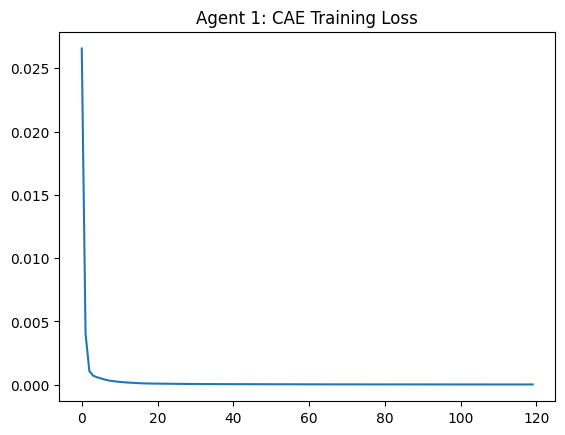

In [9]:
BATCH_SIZE = 256
EPOCHS = 120
LEARNING_RATE = 1e-4
LAMBDA_PENALTY = 1e-4
FORCE_RETRAIN_CAE = True

agent1_model = ContractiveAutoencoder(input_dim=len(NUM_COLS)).to(CONFIG['device'])
optimizer = optim.Adam(agent1_model.parameters(), lr=LEARNING_RATE)

if os.path.exists(CONFIG['agent1_path']) and not FORCE_RETRAIN_CAE:
    print(f"Found saved Agent 1 model at {CONFIG['agent1_path']}. Loading...")
    agent1_model.load_state_dict(
        torch.load(CONFIG['agent1_path'], map_location=CONFIG['device'])
    )
    agent1_model.eval()
else:
    print("Training CAE (Agent 1)...")
    train_loader = DataLoader(TensorDataset(X_train_num), batch_size=BATCH_SIZE, shuffle=True)
    loss_history = []
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in train_loader:
            x_batch = batch[0]
            optimizer.zero_grad()
            recon, latent = agent1_model(x_batch)
            loss, mse = contractive_loss(agent1_model, x_batch, recon, latent, LAMBDA_PENALTY)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.6f}")

    torch.save(agent1_model.state_dict(), CONFIG['agent1_path'])
    print(f"Agent 1 CAE model saved to {CONFIG['agent1_path']}")
    plt.plot(loss_history)
    plt.title("Agent 1: CAE Training Loss")
    plt.show()

### Agent 1 Evaluation

In [10]:
agent1_model.eval()
with torch.no_grad():
    recon_test, _ = agent1_model(X_test_num)
    loss_fn = nn.MSELoss(reduction='none')
    reconstruction_errors = torch.mean(loss_fn(recon_test, X_test_num), dim=1).cpu().numpy()

agent1_auc, _ = evaluate_single_agent("Agent 1 (CAE)", reconstruction_errors, y_test)


  Agent 1 (CAE) — Individual Evaluation
  ROC-AUC: 0.8261
  Average Precision (AP): 0.0004
  Optimal threshold (recall≥90%): 0.000009
  → Precision: 0.0002, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.55      0.71    389778
   Malicious       0.00      0.91      0.00        47

    accuracy                           0.55    389825
   macro avg       0.50      0.73      0.36    389825
weighted avg       1.00      0.55      0.71    389825

  Malicious detected: 43/47


### Agent 2 - Semantic Analysis (NLP)

In [11]:
FORCE_RETRAIN_SEMANTIC = True

class SemanticAgent:
    def __init__(self, n_clusters=50):
        self.embedder = SentenceTransformer('all-MiniLM-L6-v2', device=CONFIG['device'])
        self.n_clusters = n_clusters
        self.cluster_centroids = None

    def _prepare_texts(self, df):
        text_cols = ['email_content_text', 'http_url_text', 'http_content_text',
                     'file_names_text', 'file_content_text']
        labels = ['EMAIL_BODY', 'URLS', 'HTTP_CONTENT', 'FILES', 'FILE_CONTENT']
        parts = []
        for col, label in zip(text_cols, labels):
            series = df[col].fillna('').astype(str)
            mask = series.str.strip().ne('')
            labeled = (label + ': ' + series).where(mask, '')
            parts.append(labeled)
        combined = parts[0]
        for p in parts[1:]:
            both_nonempty = combined.ne('') & p.ne('')
            combined = combined + both_nonempty.map({True: ' | ', False: ''}) + p
        return combined.tolist()

    @staticmethod
    def _text_mask(texts):
        return [bool(t.strip()) for t in texts]

    def fit(self, df):
        print("Agent 2: Preparing Text Data (vectorized)…")
        texts = self._prepare_texts(df)
        has_text = self._text_mask(texts)
        text_indices = [i for i, h in enumerate(has_text) if h]
        text_batch = [texts[i] for i in text_indices]
        print(f"Agent 2: {len(text_batch):,} / {len(texts):,} sessions have text content.")
        if not text_batch:
            self.cluster_centroids = np.zeros((1, 384))
            return
        print("Agent 2: Generating Embeddings…")
        all_embeddings = []
        batch_size = 512
        for i in tqdm(range(0, len(text_batch), batch_size), desc="Embedding"):
            batch = text_batch[i:i + batch_size]
            emb = self.embedder.encode(batch, show_progress_bar=False)
            all_embeddings.append(emb)
        embeddings = np.vstack(all_embeddings)
        k = min(self.n_clusters, len(embeddings))
        print(f"Agent 2: Clustering into {k} centroids…")
        kmeans = MiniBatchKMeans(n_clusters=k, batch_size=4096, random_state=42, n_init=3)
        kmeans.fit(embeddings)
        self.cluster_centroids = kmeans.cluster_centers_
        print(f"Agent 2: Multi-centroid model trained — {k} clusters.")

    def predict_score(self, df):
        texts = self._prepare_texts(df)
        has_text = self._text_mask(texts)
        scores = np.zeros(len(texts))
        text_indices = [i for i, h in enumerate(has_text) if h]
        if text_indices and self.cluster_centroids is not None:
            text_batch = [texts[i] for i in text_indices]
            embeddings = self.embedder.encode(text_batch, show_progress_bar=True, batch_size=128)
            sims = cosine_similarity(embeddings, self.cluster_centroids)
            max_sim = sims.max(axis=1)
            scores[text_indices] = 1.0 - max_sim
        return scores

    def save(self, path):
        np.save(path, self.cluster_centroids)

    def load(self, path):
        self.cluster_centroids = np.load(path)


agent2 = SemanticAgent(n_clusters=50)
if os.path.exists(CONFIG['agent2_path']) and not FORCE_RETRAIN_SEMANTIC:
    print(f"Loading Agent 2 from {CONFIG['agent2_path']}...")
    agent2.load(CONFIG['agent2_path'])
else:
    print("Training Agent 2...")
    agent2.fit(train_df)
    agent2.save(CONFIG['agent2_path'])
    print(f"Agent 2 saved to {CONFIG['agent2_path']}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training Agent 2...
Agent 2: Preparing Text Data (vectorized)…
Agent 2: 1,462,520 / 1,559,108 sessions have text content.
Agent 2: Generating Embeddings…


Embedding:   0%|          | 0/2857 [00:00<?, ?it/s]

Agent 2: Clustering into 50 centroids…
Agent 2: Multi-centroid model trained — 50 clusters.
Agent 2 saved to ../SavedModels/agent2_centroid_v7.npy


### Agent 2 Evaluation

In [12]:
semantic_scores = agent2.predict_score(test_df)
agent2_auc, _ = evaluate_single_agent("Agent 2 (Semantic)", semantic_scores, y_test)

Batches:   0%|          | 0/2837 [00:00<?, ?it/s]


  Agent 2 (Semantic) — Individual Evaluation
  ROC-AUC: 0.4995
  Average Precision (AP): 0.0001
  Optimal threshold (recall≥90%): 0.159068
  → Precision: 0.0001, Recall: 0.9787

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.08      0.15    389778
   Malicious       0.00      0.98      0.00        47

    accuracy                           0.08    389825
   macro avg       0.50      0.53      0.07    389825
weighted avg       1.00      0.08      0.15    389825

  Malicious detected: 46/47


### Agent 3 - Temporal/Behavioral Baseline Agent

In [13]:
FORCE_RETRAIN_TEMPORAL = True

class TemporalBaselineAgent:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
        self.user_means = None
        self.user_stds = None
        self.global_mean = None
        self.global_std = None

    def fit(self, train_df):
        print("Agent 3: Building Historical User Baselines (on RAW features)...")
        self.global_mean = train_df[self.feature_cols].mean()
        self.global_std = train_df[self.feature_cols].std().replace(0, 1e-6)
        grouped = train_df.groupby('user')[self.feature_cols]
        self.user_means = grouped.mean()
        self.user_stds = grouped.std()
        for col in self.feature_cols:
            self.user_stds[col] = (
                self.user_stds[col].fillna(self.global_std[col]).replace(0, 1e-6)
            )
        print(f"Agent 3: Baselines built for {len(self.user_means)} unique users.")

    def predict_score(self, test_df):
        print("Agent 3: Computing Z-Score Deviations...")
        means_dict = self.user_means.to_dict('index')
        stds_dict = self.user_stds.to_dict('index')
        x = test_df[self.feature_cols].values
        means = np.zeros_like(x)
        stds = np.zeros_like(x)
        for i, user in enumerate(test_df['user']):
            if user in means_dict:
                means[i] = list(means_dict[user].values())
                stds[i] = list(stds_dict[user].values())
            else:
                means[i] = self.global_mean.values
                stds[i] = self.global_std.values
        z_scores = (x - means) / stds
        z_scores = np.clip(z_scores, -10.0, 10.0)
        temporal_anomaly_scores = np.sqrt(np.mean(z_scores**2, axis=1))
        return temporal_anomaly_scores

    def save(self, path):
        data = {
            'user_means': self.user_means, 'user_stds': self.user_stds,
            'global_mean': self.global_mean, 'global_std': self.global_std
        }
        with open(path, 'wb') as f:
            pickle.dump(data, f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.user_means = data['user_means']
        self.user_stds = data['user_stds']
        self.global_mean = data['global_mean']
        self.global_std = data['global_std']


agent3 = TemporalBaselineAgent(feature_cols=NUM_COLS)
if os.path.exists(CONFIG['agent3_path']) and not FORCE_RETRAIN_TEMPORAL:
    print(f"Loading Agent 3 from {CONFIG['agent3_path']}...")
    agent3.load(CONFIG['agent3_path'])
else:
    print("Training Agent 3...")
    agent3.fit(train_df)
    agent3.save(CONFIG['agent3_path'])
    print(f"Agent 3 saved to {CONFIG['agent3_path']}")

Training Agent 3...
Agent 3: Building Historical User Baselines (on RAW features)...
Agent 3: Baselines built for 3194 unique users.
Agent 3 saved to ../SavedModels/agent3_baselines_v7.pkl


### Agent 3 Evaluation

In [14]:
temporal_scores = agent3.predict_score(test_df)
agent3_auc, _ = evaluate_single_agent("Agent 3 (Temporal)", temporal_scores, y_test)

Agent 3: Computing Z-Score Deviations...

  Agent 3 (Temporal) — Individual Evaluation
  ROC-AUC: 0.5131
  Average Precision (AP): 0.0055
  Optimal threshold (recall≥90%): 0.481711
  → Precision: 0.0001, Recall: 0.9362

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.16      0.28    389778
   Malicious       0.00      0.94      0.00        47

    accuracy                           0.16    389825
   macro avg       0.50      0.55      0.14    389825
weighted avg       1.00      0.16      0.28    389825

  Malicious detected: 44/47


### Agent 4 - Orchestrator & Results

In [15]:
def normalize_rank(arr):
    return rankdata(arr) / len(arr)

norm_cae = normalize_rank(reconstruction_errors)
norm_nlp = normalize_rank(semantic_scores)
norm_temp = normalize_rank(temporal_scores)

w_cae = 0.40
w_temp = 0.30
w_nlp = 0.30

final_scores = (w_cae * norm_cae) + (w_temp * norm_temp) + (w_nlp * norm_nlp)

print(f"\n{'='*60}")
print(f"  Agent 4 (Orchestrator) — Fused Score Evaluation")
print(f"{'='*60}")
fused_auc = roc_auc_score(y_test, final_scores)
fused_ap = average_precision_score(y_test, final_scores)
print(f"  Fused ROC-AUC: {fused_auc:.4f}")
print(f"  Fused Average Precision: {fused_ap:.4f}")


  Agent 4 (Orchestrator) — Fused Score Evaluation
  Fused ROC-AUC: 0.7151
  Fused Average Precision: 0.0002


### Optimal Threshold Selection (Maximize Recall)

In [16]:
# Instead of fixed 95th percentile, find threshold that catches ALL malicious
# while minimizing false positives

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, final_scores)

# Strategy: find the threshold where recall == 1.0 (or as close as possible)
# Among those, pick the one with the best precision to minimize FP
target_recall = 1.0  # We want to detect ALL malicious samples

# Try different recall targets from 1.0 down to 0.8
for target in [1.0, 0.95, 0.90, 0.85, 0.80]:
    valid_mask = recalls[:-1] >= target
    if valid_mask.any():
        # Among valid thresholds, pick the one with highest precision
        valid_precisions = precisions[:-1][valid_mask]
        best_local_idx = np.argmax(valid_precisions)
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_local_idx]
        threshold = thresholds_pr[chosen_idx]
        final_precision = precisions[chosen_idx]
        final_recall = recalls[chosen_idx]
        print(f"\n  Target recall ≥ {target:.0%}:")
        print(f"    Threshold: {threshold:.6f}")
        print(f"    Precision: {final_precision:.4f}")
        print(f"    Recall:    {final_recall:.4f}")

        preds = (final_scores >= threshold).astype(int)
        n_mal = y_test.sum()
        n_detected = ((preds == 1) & (y_test == 1)).sum()
        n_fp = ((preds == 1) & (y_test == 0)).sum()
        print(f"    Malicious detected: {n_detected}/{n_mal}")
        print(f"    False positives: {n_fp}")

        if target == 1.0 and final_recall >= 1.0:
            print(f"\n  *** ALL {n_mal} malicious samples detected! ***")
            break

# Use the threshold that maximizes recall (as close to 100% as possible)
# For the final report, use target_recall = 1.0 if achievable, else 0.90
best_target = 1.0
valid_mask = recalls[:-1] >= best_target
if not valid_mask.any():
    best_target = 0.90
    valid_mask = recalls[:-1] >= best_target

if valid_mask.any():
    valid_precisions = precisions[:-1][valid_mask]
    best_local_idx = np.argmax(valid_precisions)
    actual_indices = np.where(valid_mask)[0]
    chosen_idx = actual_indices[best_local_idx]
    threshold = thresholds_pr[chosen_idx]
else:
    threshold = np.percentile(final_scores, 95)

predictions = (final_scores >= threshold).astype(int)

print(f"\n{'='*60}")
print(f"  Final Classification Report (threshold={threshold:.6f})")
print(f"{'='*60}")
print(classification_report(y_test, predictions, target_names=['Benign', 'Malicious']))
print(f"ROC-AUC Score: {fused_auc:.4f}")
print(f"Average Precision: {fused_ap:.4f}")


  Target recall ≥ 100%:
    Threshold: 0.290788
    Precision: 0.0001
    Recall:    1.0000
    Malicious detected: 47/47
    False positives: 331277

  *** ALL 47 malicious samples detected! ***

  Final Classification Report (threshold=0.290788)
              precision    recall  f1-score   support

      Benign       1.00      0.15      0.26    389778
   Malicious       0.00      1.00      0.00        47

    accuracy                           0.15    389825
   macro avg       0.50      0.58      0.13    389825
weighted avg       1.00      0.15      0.26    389825

ROC-AUC Score: 0.7151
Average Precision: 0.0002


### Score Distribution Plot

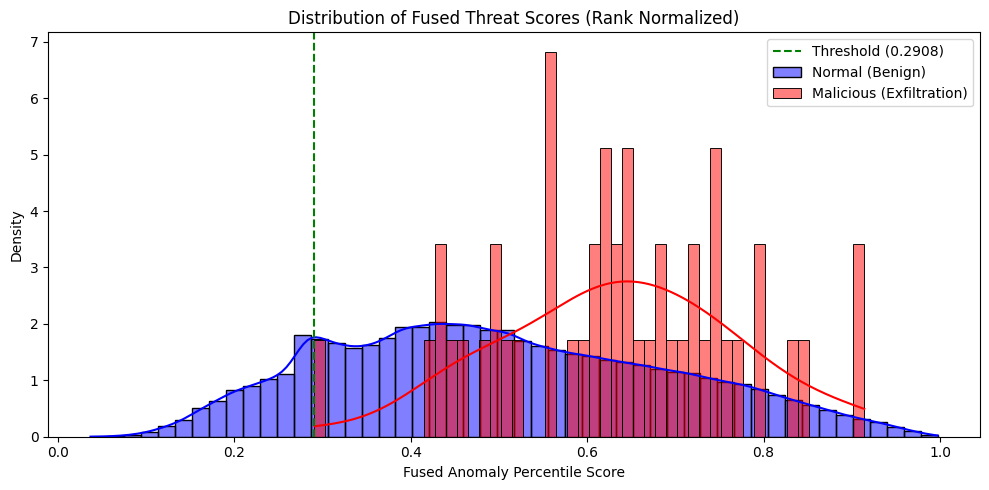

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(final_scores[y_test == 0], color='blue', label='Normal (Benign)',
             kde=True, stat="density", bins=50)
sns.histplot(final_scores[y_test == 1], color='red', label='Malicious (Exfiltration)',
             kde=True, stat="density", bins=50)
plt.axvline(threshold, color='green', linestyle='--', label=f"Threshold ({threshold:.4f})")
plt.title("Distribution of Fused Threat Scores (Rank Normalized)")
plt.xlabel("Fused Anomaly Percentile Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix

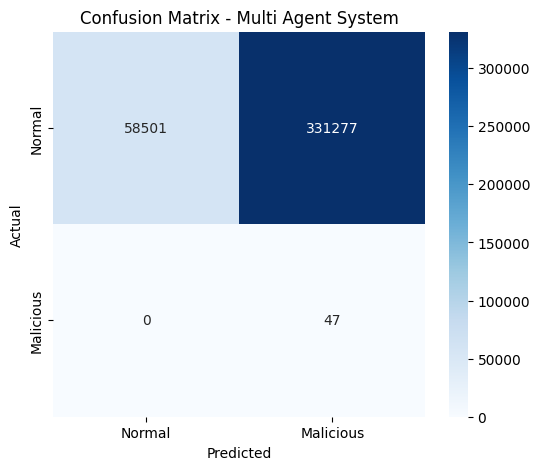

In [18]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'])
plt.title("Confusion Matrix - Multi Agent System")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### ROC Curve

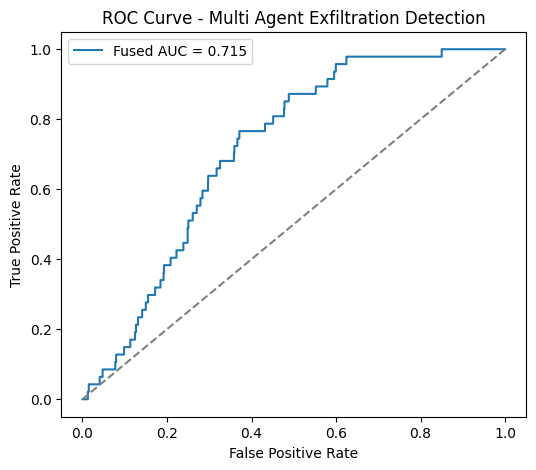

In [19]:
fpr, tpr, _ = roc_curve(y_test, final_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Fused AUC = {fused_auc:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi Agent Exfiltration Detection")
plt.legend()
plt.show()


### Agent Comparison Summary

In [20]:
print(f"\n{'='*60}")
print(f"  Agent Performance Summary (ROC-AUC)")
print(f"{'='*60}")
print(f"  Agent 1 (CAE):      {agent1_auc:.4f}")
print(f"  Agent 2 (Semantic): {agent2_auc:.4f}")
print(f"  Agent 3 (Temporal): {agent3_auc:.4f}")
print(f"  Fused (Agent 4):    {fused_auc:.4f}")
print(f"{'='*60}")


  Agent Performance Summary (ROC-AUC)
  Agent 1 (CAE):      0.8261
  Agent 2 (Semantic): 0.4995
  Agent 3 (Temporal): 0.5131
  Fused (Agent 4):    0.7151
